<a href="https://colab.research.google.com/github/rkaykothari-maker/ores5160-2026/blob/main/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

url = "https://data.cdc.gov/api/views/hksd-2xuw/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(url)

df.head()

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,Response,DataValueUnit,DataValueType,...,TopicID,QuestionID,ResponseID,DataValueTypeID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2,StratificationCategoryID3,StratificationID3
0,2020,2020,US,United States,BRFSS,Health Status,Recent activity limitation among adults,NaN,Number,Age-adjusted Mean,...,HEA,HEA04,NaN,AGEADJMEAN,SEX,SEXF,NaN,NaN,NaN,NaN
1,2015,2019,AR,Arkansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,CAN,CAN07,NaN,NMBR,SEX,SEXM,NaN,NaN,NaN,NaN
2,2015,2019,CA,California,US Cancer DVT,Cancer,"Cervical cancer mortality among all females, u...",NaN,Number,Number,...,CAN,CAN03,NaN,NMBR,OVERALL,OVR,NaN,NaN,NaN,NaN
3,2015,2019,CO,Colorado,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,CAN,CAN07,NaN,NMBR,RACE,HIS,NaN,NaN,NaN,NaN
4,2015,2019,GA,Georgia,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...",NaN,Number,Number,...,CAN,CAN05,NaN,NMBR,RACE,WHT,NaN,NaN,NaN,NaN


In [ ]:
df.to_csv("cdc_data.csv", index=False)

In [ ]:
df.shape


(309215, 34)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309215 entries, 0 to 309214
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   YearStart                  309215 non-null  int64  
 1   YearEnd                    309215 non-null  int64  
 2   LocationAbbr               309215 non-null  object 
 3   LocationDesc               309215 non-null  object 
 4   DataSource                 309215 non-null  object 
 5   Topic                      309215 non-null  object 
 6   Question                   309215 non-null  object 
 7   Response                   0 non-null       float64
 8   DataValueUnit              309215 non-null  object 
 9   DataValueType              309215 non-null  object 
 10  DataValue                  209196 non-null  float64
 11  DataValueAlt               209196 non-null  float64
 12  DataValueFootnoteSymbol    101716 non-null  object 
 13  DataValueFootnote          10

In [ ]:
df.isnull().sum()

,0
YearStart,0
YearEnd,0
LocationAbbr,0
LocationDesc,0
DataSource,0
Topic,0
Question,0
Response,309215
DataValueUnit,0
DataValueType,0


In [ ]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [ ]:
df = df.drop_duplicates()

In [ ]:
df = df.fillna("Unknown")

In [ ]:
df["locationabbr"].value_counts().head(10)

,count
locationabbr,
US,5763
TN,5750
AR,5748
KS,5748
GA,5748
ME,5748
CO,5748
HI,5748
NY,5748


In [ ]:
df["datavalue"] = pd.to_numeric(df["datavalue"], errors="coerce")
df.groupby("locationabbr")["datavalue"].mean().head(10)

,datavalue
locationabbr,
AK,61.007593
AL,389.553654
AR,265.289283
AZ,344.192300
CA,1487.591088
CO,247.408727
CT,228.546527
DC,68.191339
DE,107.631371


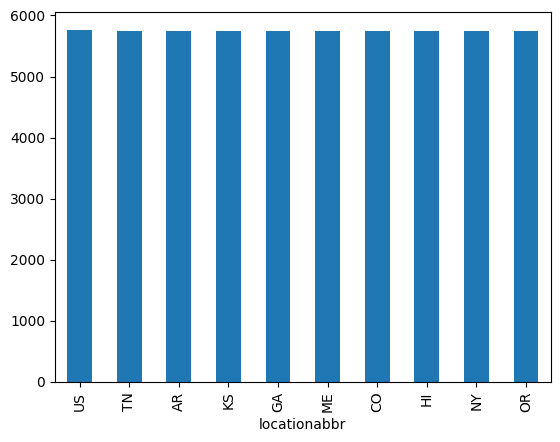

In [ ]:
import matplotlib.pyplot as plt

df["locationabbr"].value_counts().head(10).plot(kind="bar")
plt.show()

In [ ]:
df.shape
df.columns
df.head()
df.isna().sum().sort_values(ascending=False).head(20)

,0
datavalue,100019
yearstart,0
yearend,0
locationabbr,0
datasource,0
locationdesc,0
question,0
response,0
datavalueunit,0
topic,0


In [ ]:
topic_df = df[df["topic"].str.contains("Diabetes", case=False, na=False)].copy()
topic_df.shape
topic_df.head()

,yearstart,yearend,locationabbr,locationdesc,datasource,topic,question,response,datavalueunit,datavaluetype,...,topicid,questionid,responseid,datavaluetypeid,stratificationcategoryid1,stratificationid1,stratificationcategoryid2,stratificationid2,stratificationcategoryid3,stratificationid3
16,2020,2020,ID,Idaho,NVSS,Diabetes,Diabetic ketoacidosis mortality among all peop...,Unknown,Number,Number,...,DIA,DIA04,Unknown,NMBR,AGE,AGE65P,Unknown,Unknown,Unknown,Unknown
102,2019,2019,DE,Delaware,BRFSS,Diabetes,Diabetes among adults,Unknown,%,Crude Prevalence,...,DIA,DIA01,Unknown,CRDPREV,AGE,AGE4564,Unknown,Unknown,Unknown,Unknown
103,2019,2019,DE,Delaware,PRAMS,Diabetes,Gestational diabetes among women with a recent...,Unknown,%,Crude Prevalence,...,DIA,DIA02,Unknown,CRDPREV,RACE,WHT,Unknown,Unknown,Unknown,Unknown
104,2019,2019,DE,Delaware,NVSS,Diabetes,"Diabetes mortality among all people, underlyin...",Unknown,Number,Number,...,DIA,DIA03,Unknown,NMBR,SEX,SEXF,Unknown,Unknown,Unknown,Unknown
122,2019,2019,GU,Guam,BRFSS,Diabetes,Diabetes among adults,Unknown,%,Crude Prevalence,...,DIA,DIA01,Unknown,CRDPREV,SEX,SEXF,Unknown,Unknown,Unknown,Unknown


In [ ]:
topic_df.shape
topic_df.columns
topic_df.head()
topic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17318 entries, 16 to 309187
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   yearstart                  17318 non-null  int64  
 1   yearend                    17318 non-null  int64  
 2   locationabbr               17318 non-null  object 
 3   locationdesc               17318 non-null  object 
 4   datasource                 17318 non-null  object 
 5   topic                      17318 non-null  object 
 6   question                   17318 non-null  object 
 7   response                   17318 non-null  object 
 8   datavalueunit              17318 non-null  object 
 9   datavaluetype              17318 non-null  object 
 10  datavalue                  11043 non-null  float64
 11  datavaluealt               17318 non-null  object 
 12  datavaluefootnotesymbol    17318 non-null  object 
 13  datavaluefootnote          17318 non-null  object

In [ ]:
topic_df.isna().sum().sort_values(ascending=False).head(20)
topic_df.duplicated().sum()

np.int64(0)

In [ ]:
topic_df = topic_df.copy()

topic_df.columns = topic_df.columns.str.strip().str.lower().str.replace(" ", "_")

for col in ["yearstart", "yearend", "data_value", "lowconfidencelimit", "highconfidencelimit"]:
    if col in topic_df.columns:
        topic_df[col] = pd.to_numeric(topic_df[col], errors="coerce")

topic_df = topic_df.drop_duplicates()

topic_df.head()

,yearstart,yearend,locationabbr,locationdesc,datasource,topic,question,response,datavalueunit,datavaluetype,...,topicid,questionid,responseid,datavaluetypeid,stratificationcategoryid1,stratificationid1,stratificationcategoryid2,stratificationid2,stratificationcategoryid3,stratificationid3
16,2020,2020,ID,Idaho,NVSS,Diabetes,Diabetic ketoacidosis mortality among all peop...,Unknown,Number,Number,...,DIA,DIA04,Unknown,NMBR,AGE,AGE65P,Unknown,Unknown,Unknown,Unknown
102,2019,2019,DE,Delaware,BRFSS,Diabetes,Diabetes among adults,Unknown,%,Crude Prevalence,...,DIA,DIA01,Unknown,CRDPREV,AGE,AGE4564,Unknown,Unknown,Unknown,Unknown
103,2019,2019,DE,Delaware,PRAMS,Diabetes,Gestational diabetes among women with a recent...,Unknown,%,Crude Prevalence,...,DIA,DIA02,Unknown,CRDPREV,RACE,WHT,Unknown,Unknown,Unknown,Unknown
104,2019,2019,DE,Delaware,NVSS,Diabetes,"Diabetes mortality among all people, underlyin...",Unknown,Number,Number,...,DIA,DIA03,Unknown,NMBR,SEX,SEXF,Unknown,Unknown,Unknown,Unknown
122,2019,2019,GU,Guam,BRFSS,Diabetes,Diabetes among adults,Unknown,%,Crude Prevalence,...,DIA,DIA01,Unknown,CRDPREV,SEX,SEXF,Unknown,Unknown,Unknown,Unknown


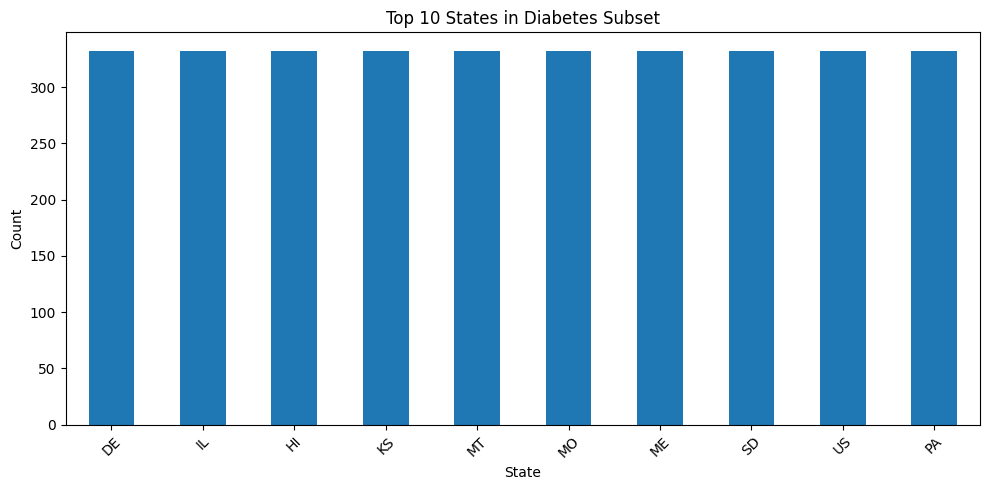

In [ ]:
topic_df["locationabbr"].value_counts().head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 States in Diabetes Subset")
plt.xlabel("State")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
topic_df.columns

Index(['yearstart', 'yearend', 'locationabbr', 'locationdesc', 'datasource',
       'topic', 'question', 'response', 'datavalueunit', 'datavaluetype',
       'datavalue', 'datavaluealt', 'datavaluefootnotesymbol',
       'datavaluefootnote', 'lowconfidencelimit', 'highconfidencelimit',
       'stratificationcategory1', 'stratification1', 'stratificationcategory2',
       'stratification2', 'stratificationcategory3', 'stratification3',
       'geolocation', 'locationid', 'topicid', 'questionid', 'responseid',
       'datavaluetypeid', 'stratificationcategoryid1', 'stratificationid1',
       'stratificationcategoryid2', 'stratificationid2',
       'stratificationcategoryid3', 'stratificationid3'],
      dtype='object')

In [ ]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [ ]:
def check_missing(df):
    missing = df.isnull().sum()
    return missing[missing > 0]

def check_duplicates(df):
    return df.duplicated().sum()

def check_negative_values(df, column):
    return (df[column] < 0).sum()

In [ ]:
df.columns

Index(['yearstart', 'yearend', 'locationabbr', 'locationdesc', 'datasource',
       'topic', 'question', 'response', 'datavalueunit', 'datavaluetype',
       'datavalue', 'datavaluealt', 'datavaluefootnotesymbol',
       'datavaluefootnote', 'lowconfidencelimit', 'highconfidencelimit',
       'stratificationcategory1', 'stratification1', 'stratificationcategory2',
       'stratification2', 'stratificationcategory3', 'stratification3',
       'geolocation', 'locationid', 'topicid', 'questionid', 'responseid',
       'datavaluetypeid', 'stratificationcategoryid1', 'stratificationid1',
       'stratificationcategoryid2', 'stratificationid2',
       'stratificationcategoryid3', 'stratificationid3'],
      dtype='object')

In [ ]:
df["datavalue"] = pd.to_numeric(df["datavalue"], errors="coerce")

In [ ]:
try:
    df["datavalue"] = pd.to_numeric(df["datavalue"], errors="coerce")
except Exception as e:
    print("Conversion error:", e)

In [ ]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [ ]:
df["datavalue"] = pd.to_numeric(df["datavalue"], errors="coerce")

In [ ]:
df = df.dropna(subset=["datavalue"])

In [ ]:
df.groupby("locationabbr")["datavalue"].mean().head(10)

,datavalue
locationabbr,
AK,61.007593
AL,389.553654
AR,265.289283
AZ,344.192300
CA,1487.591088
CO,247.408727
CT,228.546527
DC,68.191339
DE,107.631371


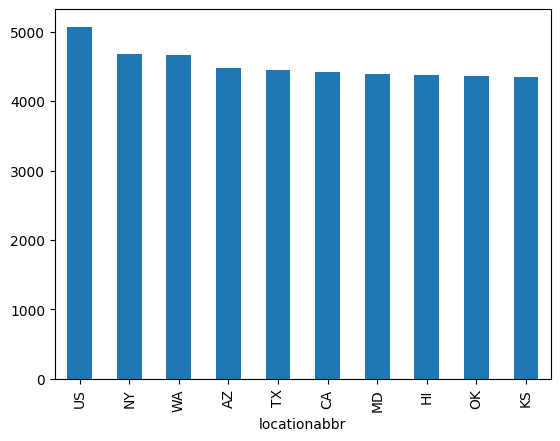

In [ ]:
import matplotlib.pyplot as plt

df["locationabbr"].value_counts().head(10).plot(kind="bar")
plt.show()

In [ ]:
def missing_report(df):
    return (df.isnull().sum() / len(df)) * 100

def duplicate_check(df):
    return df.duplicated().sum()

def range_check(df, col):
    return {
        "min": df[col].min(),
        "max": df[col].max()
    }

In [ ]:
def validate_year(df):
    return df[(df["yearstart"] < 2000) | (df["yearstart"] > 2030)]

In [ ]:
pivot_df = df.pivot_table(
    index="locationabbr",
    columns="topic",
    values="datavalue",
    aggfunc="mean"
)

In [ ]:
melted = df.melt(
    id_vars=["locationabbr", "yearstart"],
    value_vars=["datavalue"]
)

In [ ]:
state_summary = df.groupby("locationabbr")["datavalue"].mean()

In [ ]:
import sqlite3

conn = sqlite3.connect("cdc_health.db")

df.to_sql("chronic_indicators", conn, if_exists="replace", index=False)

209196

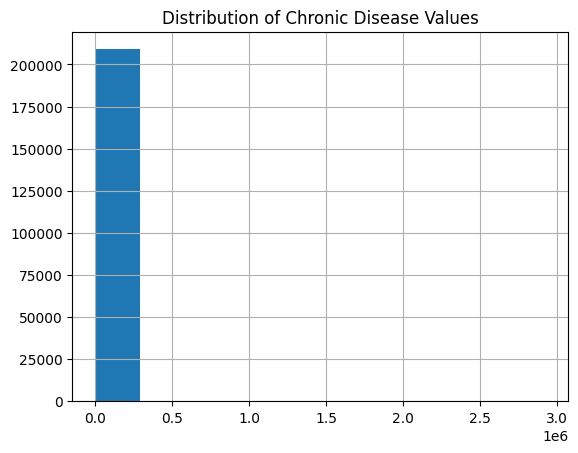

In [ ]:
import matplotlib.pyplot as plt

df["datavalue"].hist()
plt.title("Distribution of Chronic Disease Values")
plt.show()

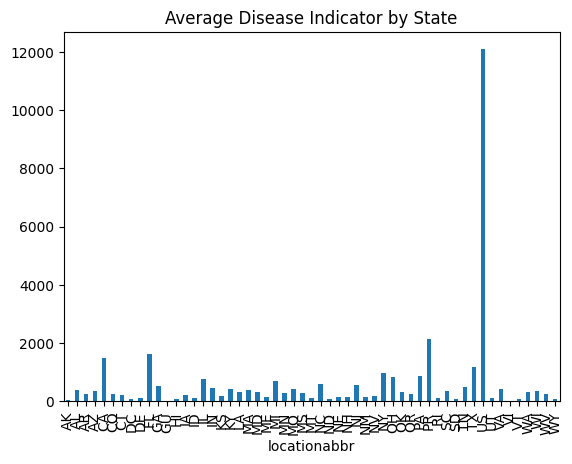

In [ ]:
df.groupby("locationabbr")["datavalue"].mean().plot(kind="bar")
plt.title("Average Disease Indicator by State")
plt.show()

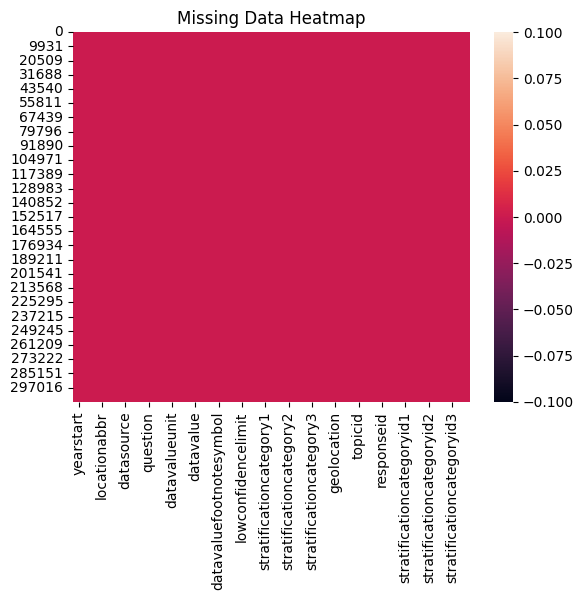

In [ ]:
import seaborn as sns

sns.heatmap(df.isnull())
plt.title("Missing Data Heatmap")
plt.show()

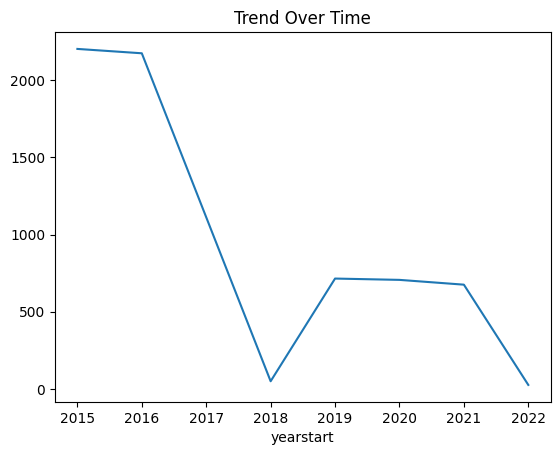

In [ ]:
df.groupby("yearstart")["datavalue"].mean().plot()
plt.title("Trend Over Time")
plt.show()

In [ ]:
import logging

logging.basicConfig(filename="logs/pipeline.log", level=logging.INFO)

logging.info("CDC dataset loaded successfully")
logging.info(f"Shape after cleaning: {df.shape}")

In [ ]:
json_data = df.to_dict(orient="records")

import json
with open("cdc_chronic.json", "w") as f:
    json.dump(json_data, f, indent=2)

In [ ]:
df.to_html("cdc_chronic.html", index=False)

In [ ]:
html = df.head(50).to_html(classes="table table-striped", index=False)

with open("cdc_chronic.html", "w") as f:
    f.write(f"""
    <html>
    <head>
        <title>CDC Chronic Disease Data</title>
        <style>
            table {{ border-collapse: collapse; width: 100%; }}
            th, td {{ border: 1px solid black; padding: 8px; }}
        </style>
    </head>
    <body>
        <h1>CDC Chronic Disease Indicators</h1>
        {html}
    </body>
    </html>
    """)

In [ ]:
def clean_data(df):
    """
    Cleans dataset by handling missing values and duplicates.
    Returns cleaned dataframe.
    """